# Crop Yield Prediction — Model Exploration & SHAP Analysis

Corn yield prediction across 4 states (IA, IL, NE, NC), 2010-2023, fusing:
- **NDVI** (MODIS, masked to corn pixels via USDA Cropland Data Layer), monthly (Jun/Jul/Aug)
- **Weather** (PRISM precip/temp), monthly (Jun/Jul/Aug)
- **Soil** (OpenLandMap: organic carbon, pH, clay%, sand%, water capacity), static per county

Two checkpoints are compared:
- `early_season`: only Jun+Jul features visible — simulates an in-season forecast
- `pre_harvest`: Jun+Jul+Aug features visible — full-season, post-hoc

All model evaluation uses **leave-one-year-out cross-validation**, so a model is
never trained and tested on the same growing season.


In [1]:
import os
import sys

# scripts/data paths are relative to the project root, not notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

from config import CHECKPOINTS, STATES
from model_utils import load_checkpoint_table, prep_features, numeric_feature_cols, MODELS, TARGET


## 1. Dataset overview

In [2]:
pre_harvest = load_checkpoint_table("pre_harvest")
early_season = load_checkpoint_table("early_season")

print(f"pre_harvest: {pre_harvest.shape[0]} rows, {pre_harvest.shape[1]} columns")
print(f"early_season: {early_season.shape[0]} rows, {early_season.shape[1]} columns")
pre_harvest.head()


pre_harvest: 4251 rows, 26 columns
early_season: 4251 rows, 21 columns


,year,state_fips,state_alpha,county_fips,county_name,yield_bu_acre,ndvi_jun,ndvi_jul,ndvi_aug,precip_sum_jun,...,tmax_jul,tmax_aug,tmin_jun,tmin_jul,tmin_aug,soil_organic_carbon,soil_ph,soil_clay_pct,soil_sand_pct,soil_water_content_33kpa
0,2010,19,IA,1,ADAIR,139.1,0.763149,0.830315,0.781795,302.192093,...,29.222106,29.781185,16.516170,19.099346,18.035215,3.169339,62.109945,27.775166,17.047408,25.720533
1,2011,19,IA,1,ADAIR,152.8,0.698664,0.851762,0.820304,177.039468,...,31.382872,28.558044,16.065833,20.840860,16.748522,3.169339,62.109945,27.775166,17.047408,25.720533
2,2012,19,IA,1,ADAIR,104.4,0.738437,0.740861,0.612533,89.208568,...,34.334171,29.855646,16.617034,19.867134,14.747437,3.169339,62.109945,27.775166,17.047408,25.720533
3,2013,19,IA,1,ADAIR,137.8,0.619045,0.806936,0.753149,108.633891,...,28.884680,29.472189,15.681394,16.782242,16.433685,3.169339,62.109945,27.775166,17.047408,25.720533
4,2014,19,IA,1,ADAIR,169.3,0.772119,0.825642,0.816519,238.747271,...,26.855865,26.923682,16.195539,15.114154,17.618313,3.169339,62.109945,27.775166,17.047408,25.720533


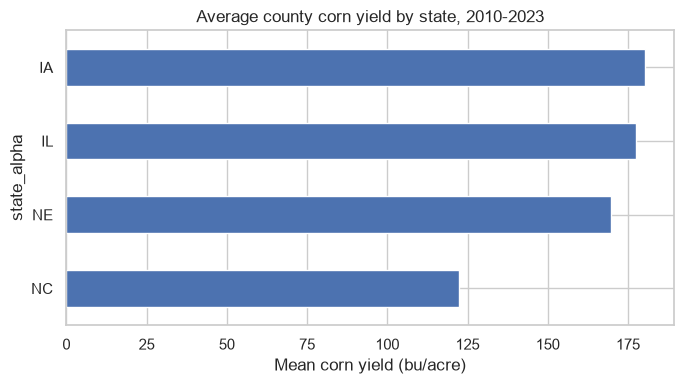

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
state_means = pre_harvest.groupby("state_alpha")[TARGET].mean().sort_values()
state_means.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Mean corn yield (bu/acre)")
ax.set_title("Average county corn yield by state, 2010-2023")
plt.tight_layout()
plt.show()


## 2. Model comparison

Linear Regression, Random Forest, Gradient Boosting, and a small MLP neural net,
compared at both checkpoints via leave-one-year-out CV.


In [4]:
summary = pd.read_csv("data/processed/model_comparison_summary.csv")
summary.pivot(index="model", columns="checkpoint", values=["mean_mae", "median_r2"])


mean_mae                median_r2            
checkpoint       early_season pre_harvest early_season pre_harvest
model                                                             
GradientBoosting    15.418808   13.190299     0.670438    0.755824
LinearRegression    52.157458   38.491455     0.630270    0.673687
MLP (small NN)      17.367799   14.808273     0.606576    0.721714
RandomForest        15.116518   14.480416     0.669311    0.707635

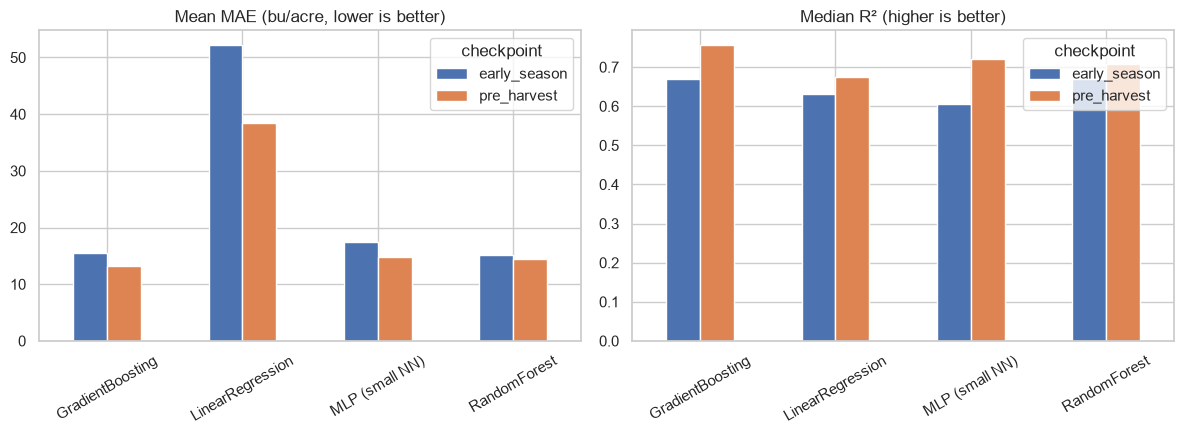

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric, title in zip(axes, ["mean_mae", "median_r2"],
                              ["Mean MAE (bu/acre, lower is better)", "Median R² (higher is better)"]):
    piv = summary.pivot(index="model", columns="checkpoint", values=metric)
    piv.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 3. Feature engineering: does county-trend detrending + anomaly features help?

Two known gaps in the baseline: no time trend (yields drift upward from genetics/practices,
independent of a given year's weather) and raw (not anomaly) NDVI/weather values, which force
the model to learn per-county baselines instead of just the year-to-year weather signal.

Both the per-county yield trend and per-county feature means are fit on the **training fold
only** inside each CV split, so nothing about the held-out year leaks in.


In [6]:
fe = pd.read_csv("data/processed/feature_engineering_comparison.csv")
fe_piv = fe.pivot(index=["checkpoint", "model"], columns="variant", values=["mean_mae", "median_r2"])
fe_piv


mean_mae            median_r2           
variant                         baseline engineered  baseline engineered
checkpoint   model                                                      
early_season GradientBoosting  15.418808  14.439603  0.670438   0.688476
             MLP (small NN)    17.367799  15.680576  0.606576   0.677495
             RandomForest      15.116518  14.227738  0.669311   0.697699
pre_harvest  GradientBoosting  13.190299  13.511274  0.755824   0.726939
             MLP (small NN)    14.808273  13.699208  0.721714   0.734968
             RandomForest      14.480416  13.673484  0.707635   0.722738

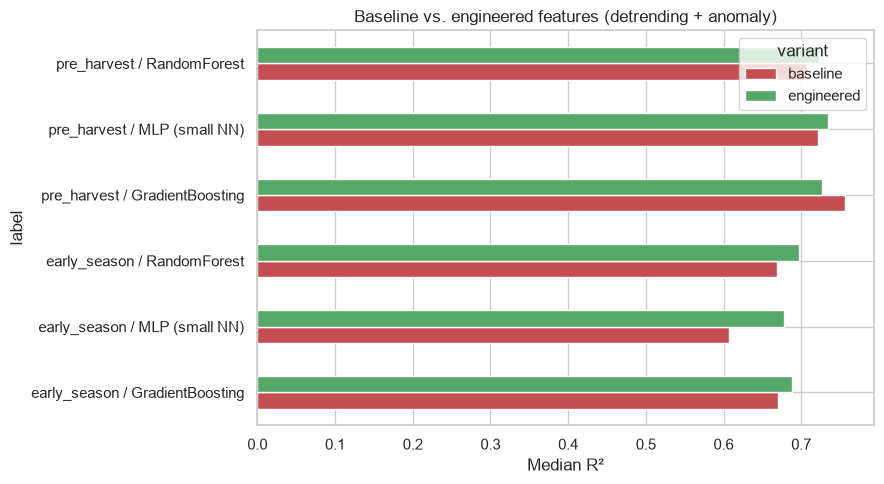

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
fe["label"] = fe["checkpoint"] + " / " + fe["model"]
piv = fe.pivot(index="label", columns="variant", values="median_r2")
piv.plot(kind="barh", ax=ax, color=["#C44E52", "#55A868"])
ax.set_xlabel("Median R²")
ax.set_title("Baseline vs. engineered features (detrending + anomaly)")
plt.tight_layout()
plt.show()


**Read**: engineered features (trend + anomaly) improve Random Forest and the MLP at both
checkpoints, and help Gradient Boosting at the early-season checkpoint. The one exception is
Gradient Boosting at pre-harvest, where it was already the strongest baseline and the extra
feature dimensionality slightly hurt it — a reminder that "more engineered features" isn't a
uniform win, it depends on how much headroom the base model already has.


## 4. SHAP feature importance

Using **Gradient Boosting on the pre-harvest checkpoint** — the strongest baseline model — with
SHAP's `TreeExplainer` (exact and fast for tree ensembles, unlike the general-purpose
`KernelExplainer` needed for the MLP).

The model here is trained on the full dataset (not a single CV fold) purely to get a stable,
representative view of feature importance — this is an explanation of what the model has
learned, not a held-out performance number (see section 2 for that).


In [8]:
import shap
from sklearn.ensemble import GradientBoostingRegressor

df_prepped, features = prep_features(pre_harvest)
gb = GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=42)
gb.fit(df_prepped[features], df_prepped[TARGET])

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(df_prepped[features])


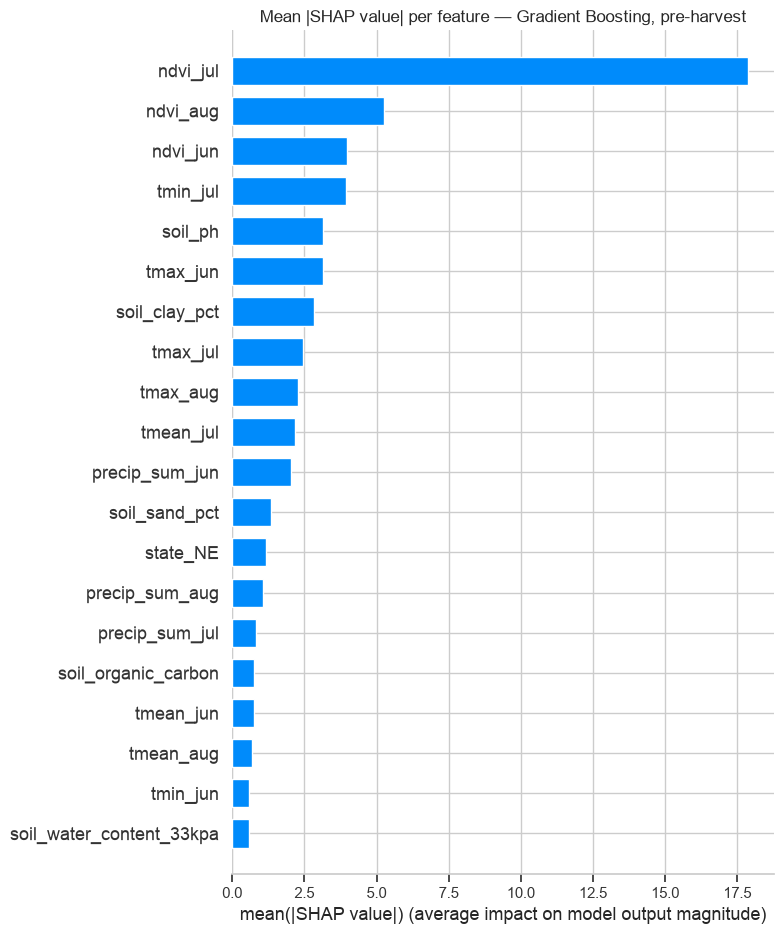

In [9]:
shap.summary_plot(shap_values, df_prepped[features], plot_type="bar", show=False)
plt.title("Mean |SHAP value| per feature — Gradient Boosting, pre-harvest")
plt.tight_layout()
plt.show()


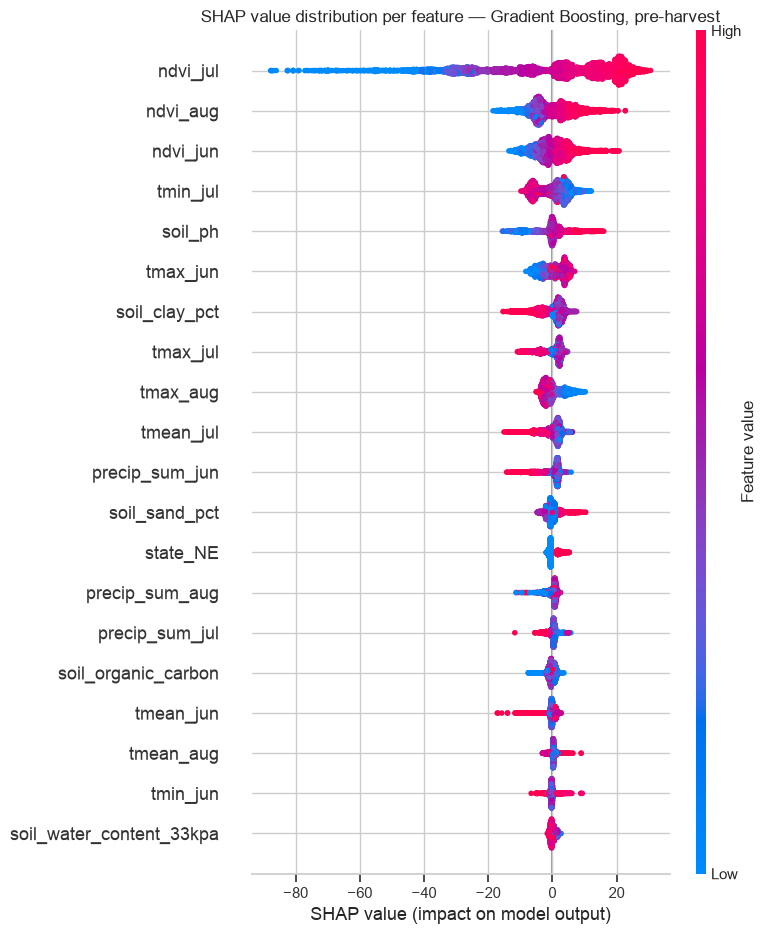

In [10]:
shap.summary_plot(shap_values, df_prepped[features], show=False)
plt.title("SHAP value distribution per feature — Gradient Boosting, pre-harvest")
plt.tight_layout()
plt.show()


## 5. Takeaways

- Expanding from one flat season-average feature set to monthly (Jun/Jul/Aug) NDVI + weather,
  plus static soil properties, was the single biggest lift in this project: pre-harvest R² rose
  from ~0.67 to ~0.76 (Gradient Boosting).
- County-trend detrending and NDVI/weather anomaly features generally help further, especially
  for the neural net, though not uniformly — Gradient Boosting's pre-harvest result didn't
  benefit from it.
- SHAP shows which features the winning model actually leans on — see the bar chart above for
  the ranked list, and the beeswarm for the direction of each feature's effect (e.g. does higher
  NDVI push predicted yield up or down, and by how much).
- Known gaps still open: no field-level or state-specific season-calendar adjustment (NC's
  season runs ~3-4 weeks ahead of the Corn Belt states, but shares the same Jun/Jul/Aug windows
  here), and no soil-moisture (SMAP) or terrain features yet.
